In [1]:
import matplotlib.pyplot as plt
from soilgrids import SoilGrids

In [2]:
soil_grids = SoilGrids()

In [4]:
soil_grids.map_services

service id: bdod
variable name: Bulk density
variable units: cg/cm3
service link: https://maps.isric.org/mapserv?map=/map/bdod.map
service id: cec
variable name: Citation exchange capacity at ph7
variable units: mmol(c)/kg
service link: https://maps.isric.org/mapserv?map=/map/cec.map
service id: cfvo
variable name: Coarse fragments volumetric
variable units: cm3/dm3 (vol‰)
service link: https://maps.isric.org/mapserv?map=/map/cfvo.map
service id: clay
variable name: Clay content
variable units: g/kg
service link: https://maps.isric.org/mapserv?map=/map/clay.map
service id: nitrogen
variable name: Nitrogen
variable units: cg/kg
service link: https://maps.isric.org/mapserv?map=/map/nitrogen.map
service id: phh2o
variable name: Soil pH in H2O
variable units: pH*10
service link: https://maps.isric.org/mapserv?map=/map/phh2o.map
service id: sand
variable name: Sand content
variable units: g/kg
service link: https://maps.isric.org/mapserv?map=/map/sand.map
service id: silt
variable name: Sil

In [6]:

soil_grids.get_coverage_list("wrb")

'wrb' map service includes 31 coverages(maps)
Acrisols
Albeluvisols
Alisols
Andosols
Arenosols
Calcisols
Cambisols
Chernozems
Cryosols
Durisols
Ferralsols
Fluvisols
Gleysols
Gypsisols
Histosols
Kastanozems
Leptosols
Lixisols
Luvisols
MostProbable
Nitisols
Phaeozems
Planosols
Plinthosols
Podzols
Regosols
Solonchaks
Solonetz
Stagnosols
Umbrisols
Vertisols


In [8]:
soil_grids.get_coverage_info("wrb", "Fluvisols")

Supported CRS: 
urn:ogc:def:crs:EPSG::4326
urn:ogc:def:crs:EPSG::152160
urn:ogc:def:crs:EPSG::3857
urn:ogc:def:crs:EPSG::54009
urn:ogc:def:crs:EPSG::54012
urn:ogc:def:crs:EPSG::4326

Coverage Bounding Box: 
EPSG:4326
(-180.0, -56.0008103940592, 179.999942400152, 83.999167206)
EPSG:4326
(-180.0, -56.0008103940592, 179.999942400152, 83.999167206)



In [14]:
crs = "urn:ogc:def:crs:EPSG::4326"
west, south, east, north = [85.0, 21.5, 89.5, 27.2]
width = 316
height = 275

In [18]:
data = soil_grids.get_coverage_data(
    service_id="wrb",
    coverage_id="Vertisols",
    west=west,
    south=south,
    east=east,
    north=north,
    crs=crs,
    width=width,
    height=height,
    local_file=False,
    output="test.tif"
)

In [19]:
for key, value in soil_grids.metadata.items():
    print(f"{key}: {value}")

# show GeoTiff file path
print(f"file path: {soil_grids.tif_file}")

variable_name: World Reference Base (WRB) classes and probabilities
variable_units: none
service_url: https://maps.isric.org/mapserv?map=/map/wrb.map
service_id: wrb
coverage_id: Vertisols
crs: urn:ogc:def:crs:EPSG::4326
bounding_box: (85.0, 21.5, 89.5, 27.2)
grid_res: [0.014240506329113917, 0.02072727272727273]
file path: c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\soil_type_classification\models\test.tif


Text(0.5, 1.0, 'Mean pH between 0 and 5 cm soil depth in Senegal')

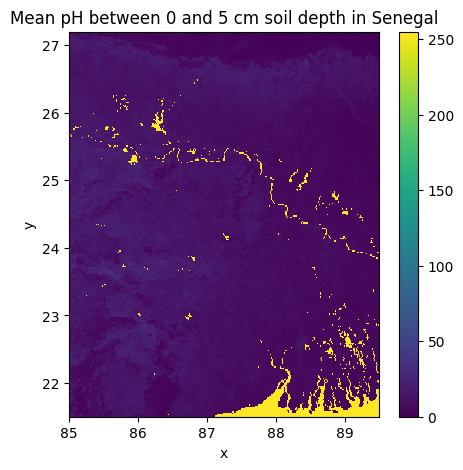

In [21]:
data.plot(figsize=(5, 5), vmin=0)
plt.title("Mean pH between 0 and 5 cm soil depth in Senegal")

In [22]:
import requests

def get_soil_by_coordinates(lat, lon):
    """Get soil data for a specific coordinate point"""
    url = "https://rest.isric.org/soilgrids/v2.0/classification/query"
    
    params = {
        "lon": lon,
        "lat": lat,
        "number_classes": 3  # top 3 soil classifications
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    return data

# Example usage
lat, lon = 28.6139, 77.2090  # New Delhi
result = get_soil_by_coordinates(lat, lon)
print(result)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import rasterio
from rasterio.transform import rowcol

def extract_value_at_coordinate(tif_file, lat, lon):
    with rasterio.open(tif_file) as src:
        # Reproject lat/lon to the raster's CRS if needed
        from pyproj import Transformer
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        x, y = transformer.transform(lon, lat)

        row, col = rowcol(src.transform, x, y)
        
        # Bounds check
        if 0 <= row < src.height and 0 <= col < src.width:
            value = src.read(1)[row, col]
            print(f"Soil value at ({lat}, {lon}): {value}")
            print(f"NoData: {src.nodata}")
            return value
        else:
            print("Coordinate is outside the raster extent.")
            return None

# Usage
extract_value_at_coordinate("test.tif", lat=28.61Z

Coordinate is outside the raster extent.
